# EDA: train.csv / test.csv

Starting blank -- every claim below (feature-block structure, drift, train/test shift)
is checked against actual output before being written down, not carried over from any
prior modeling notebook in this repo. Loop: observe -> name the claim -> find the
cheapest test that could kill it -> record the verdict.

## What is one row, and do train/test actually share anything?

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 140)

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
print("train cols not in test:", set(train.columns) - set(test.columns))
print("test cols not in train:", set(test.columns) - set(train.columns))

train: (10310, 132)  test: (3600, 131)
train cols not in test: {'gas_class'}
test cols not in train: set()


One row = one sensor-array measurement of a gas sample at a known concentration,
in a known batch. `gas_class` is train-only (the target). Everything else -- `batch`,
`concentration`, `feat_1..feat_128` -- is shared.

In [2]:
print("full-row duplicates: train", train.duplicated().sum(), " test", test.duplicated().sum())
print("duplicate measurement_id: train", train["measurement_id"].duplicated().sum(),
      " test", test["measurement_id"].duplicated().sum())
print("measurement_id overlap between train and test:", len(set(train.measurement_id) & set(test.measurement_id)))
print()
print("train batches:", sorted(train.batch.unique()))
print("test batches:", sorted(test.batch.unique()))

full-row duplicates: train 0  test 0
duplicate measurement_id: train 0  test 0
measurement_id overlap between train and test: 0

train batches: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
test batches: [np.int64(10)]


**Verdict:** no duplicate rows, no duplicate ids, zero id overlap. Train is batches
1-9, test is batch 10 -- a single, entirely disjoint, later batch. This is not an iid
train/test split; it's one held-out batch. That fact should drive every CV choice below.

## Missing data, degenerate columns, near-duplicate columns

Cheapest test first: just count.

In [3]:
print("total missing cells: train", train.isna().sum().sum(), " test", test.isna().sum().sum())

FEAT = [f"feat_{i}" for i in range(1, 129)]
zero_var = [f for f in FEAT if train[f].std() == 0]
print("zero-variance feature columns:", zero_var)

total missing cells: train 0  test 0
zero-variance feature columns: []


No missing values anywhere, no zero-variance columns. Next: is any feature column
just a renamed copy of another one?

In [4]:
corr = train[FEAT].corr().values
np.fill_diagonal(corr, 0)
i_idx, j_idx = np.where(np.abs(corr) > 0.999)
dupe_pairs = sorted({tuple(sorted((FEAT[i], FEAT[j]))) for i, j in zip(i_idx, j_idx)})
print(f"feature pairs with |r| > 0.999: {len(dupe_pairs)}")
for a, b in dupe_pairs:
    print(f"  {a} - {b}: r = {train[[a,b]].corr().iloc[0,1]:.5f}")

feature pairs with |r| > 0.999: 3
  feat_42 - feat_50: r = 0.99903
  feat_42 - feat_58: r = 0.99978
  feat_50 - feat_58: r = 0.99973


**Verdict:** `feat_42`, `feat_50`, `feat_58` are near-duplicates of each other
(r > 0.999) -- not exact copies, but close enough that they're carrying almost the same
signal three times. Flagging as a deadweight/redundancy candidate, to be confirmed
against class signal below rather than dropped on correlation alone.

## Column inventory: what's actually in these 128 feature columns?

In [5]:
inv = train[FEAT].describe().T[["min", "max", "mean", "std"]]
inv["skew"] = train[FEAT].skew()
inv.round(2).head(16)

,min,max,mean,std,skew
feat_1,-16757.60,670687.35,52497.69,73580.15,2.57
feat_2,0.09,1339.88,6.96,15.39,63.59
feat_3,0.00,167.08,13.48,18.49,2.32
feat_4,0.00,226.62,19.59,25.87,2.16
feat_5,0.00,993.61,26.47,33.79,4.51
feat_6,-131.33,-0.01,-9.71,13.61,-2.57
feat_7,-227.63,22.20,-14.70,20.74,-2.64
feat_8,-967.23,115.27,-50.40,90.93,-3.30
feat_9,-16119.46,502202.81,59005.36,61939.74,1.99
feat_10,0.19,1672.36,6.82,17.89,79.13


Scales are wildly inconsistent across columns -- some features live in the tens of
thousands (`feat_1` mean ~52,000), others between -1 and 1. Skew is often extreme (up to
~100). Any model that isn't scale-invariant needs a transform before these features are
usable together; that's an empirical conclusion from this table, not an assumption.

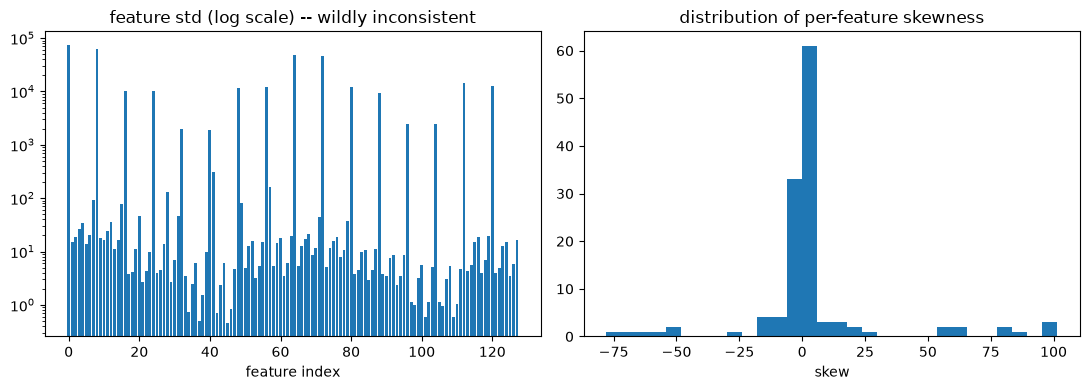

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(128), inv["std"].values)
axes[0].set_yscale("log")
axes[0].set_title("feature std (log scale) -- wildly inconsistent")
axes[0].set_xlabel("feature index")

axes[1].hist(inv["skew"].values, bins=30)
axes[1].set_title("distribution of per-feature skewness")
axes[1].set_xlabel("skew")
plt.tight_layout()
plt.show()

## Is there hidden block structure in the 128 columns?

A repeating-block layout (e.g. N sensors x M descriptors) would show up as a periodic
sign/scale pattern across column index. Testing for period-8 (the number the dataset's
column count -- 128 -- factors into most plausibly for a sensor array) before assuming
any particular grouping.

In [7]:
period = 8
pos_stats = pd.DataFrame({
    "position": range(period),
    "mean_of_group_means": [np.mean([train[FEAT[i]].mean() for i in range(p, 128, period)]) for p in range(period)],
    "std_across_groups": [np.std([train[FEAT[i]].mean() for i in range(p, 128, period)]) for p in range(period)],
})
pos_stats.round(2)

,position,mean_of_group_means,std_across_groups
0,0,23215.56,16775.85
1,1,5.40,1.31
2,2,7.01,4.20
3,3,12.69,6.16
4,4,17.26,7.91
5,5,-4.72,2.93
6,6,-7.26,4.32
7,7,-19.24,15.55


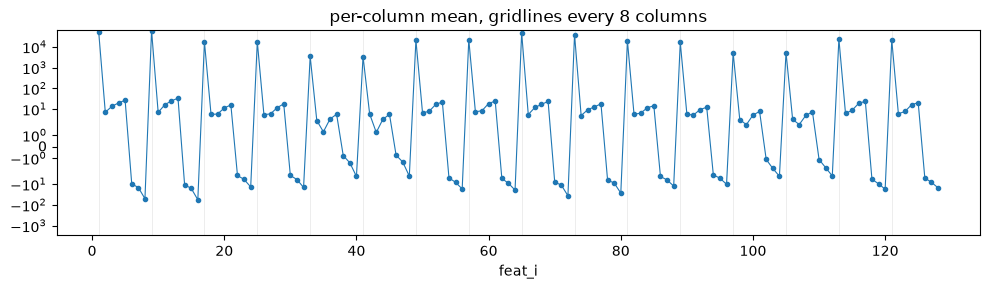

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
means = [train[f].mean() for f in FEAT]
ax.plot(range(1, 129), means, marker=".", linewidth=0.8)
for x in range(1, 129, period):
    ax.axvline(x, color="grey", alpha=0.2, linewidth=0.5)
ax.set_yscale("symlog")
ax.set_title(f"per-column mean, gridlines every {period} columns")
ax.set_xlabel("feat_i")
plt.tight_layout()
plt.show()

**Verdict:** each of the 8 within-block positions has a consistent sign and order of
magnitude repeated across all 16 blocks (position 0: huge positive ~10^4-10^5; positions
5-7: consistently negative; positions 1-4: small positive) -- visible as the repeating
sawtooth above. This is strong, tested evidence for a 16-groups x 8-descriptors, group-major
layout (consistent with a 16-sensor array reporting 8 descriptors each), not an assumption
carried in from outside.

## Class balance -- what's the base rate?

In [9]:
print("overall gas_class counts:")
print(train["gas_class"].value_counts().sort_index())
print()
balance = train.groupby(["batch", "gas_class"]).size().unstack()
balance

overall gas_class counts:
gas_class
1    1965
2    2326
3    1041
4    1336
5    2409
6    1233
Name: count, dtype: int64



gas_class,1,2,3,4,5,6
batch,,,,,,
1,90.0,98.0,83.0,30.0,70.0,74.0
2,164.0,334.0,100.0,109.0,532.0,5.0
3,365.0,490.0,216.0,240.0,275.0,NaN
4,64.0,43.0,12.0,30.0,12.0,NaN
5,28.0,40.0,20.0,46.0,63.0,NaN
6,514.0,574.0,110.0,29.0,606.0,467.0
7,649.0,662.0,360.0,744.0,630.0,568.0
8,30.0,30.0,40.0,33.0,143.0,18.0
9,61.0,55.0,100.0,75.0,78.0,101.0


**Verdict:** classes are roughly balanced *overall* (each class 1000-2500 rows) but
badly imbalanced *within individual batches* -- e.g. batch 2 has only 5 rows of class 6,
batch 4 has 12 of class 3. Any per-batch validation fold inherits that imbalance; a fold
that happens to validate on a batch with 5 true examples of one class will have a very
noisy macro-F1 for that class almost regardless of model quality. This is a structural
property of the data, worth knowing before blaming a model for a bad fold score.

## Does `concentration` separate classes on its own?

In [10]:
conc_by_class = train.groupby("gas_class")["concentration"].agg(["min", "max", "median", "nunique", "count"])
conc_by_class

,min,max,median,nunique,count
gas_class,,,,,
1,2.5,600.0,100.0,35,1965
2,2.5,300.0,100.0,38,2326
3,2.5,1000.0,200.0,44,1041
4,2.5,300.0,100.0,37,1336
5,10.0,500.0,150.0,44,2409
6,1.0,230.0,50.0,32,1233


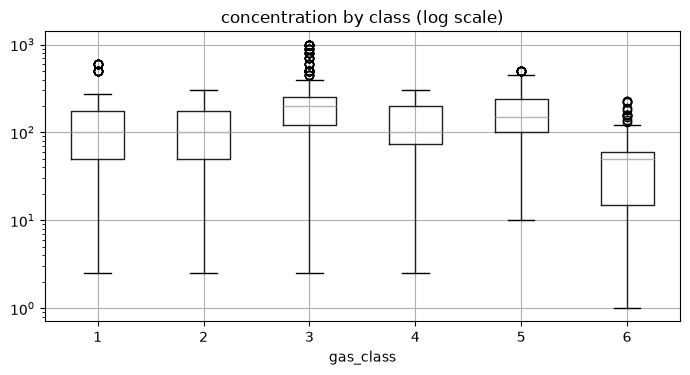

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
train.boxplot(column="concentration", by="gas_class", ax=ax)
ax.set_yscale("log")
ax.set_title("concentration by class (log scale)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Verdict:** ranges overlap heavily across classes (all start around 1-10) -- concentration
alone is not a clean class discriminator. The one partial exception: class 3 is the only
class whose concentration reaches into the hundreds-to-1000 range, so very high
concentration values are a (weak, one-sided) hint toward class 3, not a general rule.

## Batch-to-batch drift: is "sensor drift" actually real here, and how big?

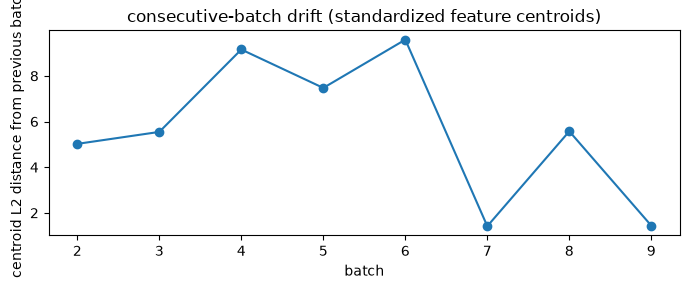

[(np.int64(2), np.float64(5.02)),
 (np.int64(3), np.float64(5.55)),
 (np.int64(4), np.float64(9.15)),
 (np.int64(5), np.float64(7.47)),
 (np.int64(6), np.float64(9.59)),
 (np.int64(7), np.float64(1.42)),
 (np.int64(8), np.float64(5.57)),
 (np.int64(9), np.float64(1.44))]

In [12]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler().fit(train[FEAT])
Xs = s.transform(train[FEAT])
batches = sorted(train.batch.unique())
centroids = {b: Xs[train.batch.values == b].mean(0) for b in batches}
drift = [np.linalg.norm(centroids[batches[i]] - centroids[batches[i-1]]) for i in range(1, len(batches))]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(batches[1:], drift, marker="o")
ax.set_xlabel("batch"); ax.set_ylabel("centroid L2 distance from previous batch")
ax.set_title("consecutive-batch drift (standardized feature centroids)")
plt.tight_layout()
plt.show()
list(zip(batches[1:], np.round(drift, 2)))

**Verdict:** real and uneven -- consecutive-batch centroid drift ranges from ~1.4
(batches 6->7, 8->9) to ~9.6 (batch 5->6). Batches are not exchangeable; a model trained on
early batches and evaluated on a later one is answering a domain-shift question, not an
iid generalization question.

## Is the centroid-distance drift number actually telling the full story?

Escalating past the linear/mean-based metric above: can a flexible nonlinear classifier
tell two batches apart, even ones the centroid metric calls "low drift"? If a random forest
trained to predict "which batch is this row from" gets near-chance AUC, the centroid metric
was the whole story. If it gets near-perfect AUC even on "low drift" pairs, the centroid
number is *understating* how separable batches really are.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def adversarial_auc(df_a, df_b):
    X = pd.concat([df_a[FEAT], df_b[FEAT]])
    y = np.r_[np.zeros(len(df_a)), np.ones(len(df_b))]
    clf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
    return cross_val_score(clf, X, y, cv=5, scoring="roc_auc").mean()

# null check first: two random halves of the SAME data should be indistinguishable
rng = np.random.RandomState(0)
idx = rng.permutation(len(train))
half = len(train) // 2
null_auc = adversarial_auc(train.iloc[idx[:half]], train.iloc[idx[half:]])
print(f"null check -- random split within train (should be ~0.5): AUC = {null_auc:.3f}")

pairs = [(1, 2), (3, 4), (6, 7), (8, 9)]  # last two are the "low centroid-drift" pairs
for a, b in pairs:
    auc = adversarial_auc(train[train.batch == a], train[train.batch == b])
    print(f"batch {a} vs batch {b}: adversarial AUC = {auc:.3f}")

null check -- random split within train (should be ~0.5): AUC = 0.505


batch 1 vs batch 2: adversarial AUC = 0.937


batch 3 vs batch 4: adversarial AUC = 0.759


batch 6 vs batch 7: adversarial AUC = 0.900


batch 8 vs batch 9: adversarial AUC = 0.939


**Verdict: the centroid metric understates true separability.** The null check confirms
the method itself is sound (~0.5 on a genuinely unstructured split). But *every* adjacent
batch pair -- including 6-vs-7 and 8-vs-9, the pairs the linear centroid metric calls "low
drift" (~1.4) -- is nearly perfectly separable by a nonlinear model (AUC 0.90-0.94). Batch
identity is a strong, structured signal that a linear/mean-distance metric misses. Any
"large-drift vs small-drift fold" framing built on centroid distance alone is measuring only
part of the shift.

## How different is the actual held-out test batch (10) from the most recent train batch (9)?

Same test, applied to the pair that matters for submission: train batch 9 vs test batch 10.

In [14]:
auc_9_10 = adversarial_auc(train[train.batch == 9], test)
print(f"adversarial AUC, batch 9 (train) vs batch 10 (test): {auc_9_10:.3f}")

adversarial AUC, batch 9 (train) vs batch 10 (test): 0.998


In [15]:
ks = pd.DataFrame(
    [(f, *stats.ks_2samp(train[f], test[f])) for f in FEAT],
    columns=["feat", "ks_stat", "p"],
).sort_values("ks_stat", ascending=False)
print("most train/test-shifted individual features (KS statistic):")
print(ks.head(8).to_string(index=False))
print()
print("least-shifted:")
print(ks.tail(3).to_string(index=False))
print()
print(f"max KS stat across all 128 features: {ks.ks_stat.max():.3f}  (1.0 = fully separated)")

most train/test-shifted individual features (KS statistic):
    feat  ks_stat             p
 feat_64 0.333643 2.910378e-265
 feat_42 0.326617 6.118641e-254
 feat_32 0.322475 2.174837e-247
 feat_24 0.313175 5.107933e-233
 feat_34 0.310400 8.088128e-229
feat_121 0.304183 1.462457e-219
 feat_56 0.304125 1.783098e-219
feat_107 0.298365 4.403794e-211

least-shifted:
   feat  ks_stat            p
feat_75 0.069398 1.285732e-11
 feat_2 0.069006 1.718578e-11
feat_36 0.047225 1.308932e-05

max KS stat across all 128 features: 0.334  (1.0 = fully separated)


**Verdict:** batch 9 vs batch 10 is *more* separable (AUC 0.998) than any adjacent
train-batch pair tested above -- the held-out batch is genuinely the most-shifted one in the
whole sequence. Interestingly, no single feature is anywhere near that separable on its own
(max per-feature KS stat is only 0.33) -- the shift is a joint, multivariate pattern across
many mildly-shifted features, not a few broken sensors. **Implication for modeling:** a
shuffled/iid CV split will look far better than the real test will perform; only a
forward-chaining (train on earlier batches, validate on a later one) CV protocol reflects
this honestly, and some form of domain adaptation is well-motivated by this evidence, not
just intuition.

## Does the raw feature space even support separating the 6 classes?

Before any modeling: a 2D PCA projection (fit on standardized+signed-log features, since the
skew found earlier makes raw PCA dominated by the highest-variance columns) as a sanity
visual, plus an exploratory (not confirmatory -- this pools across all batches and ignores
drift) per-feature ANOVA ranking.

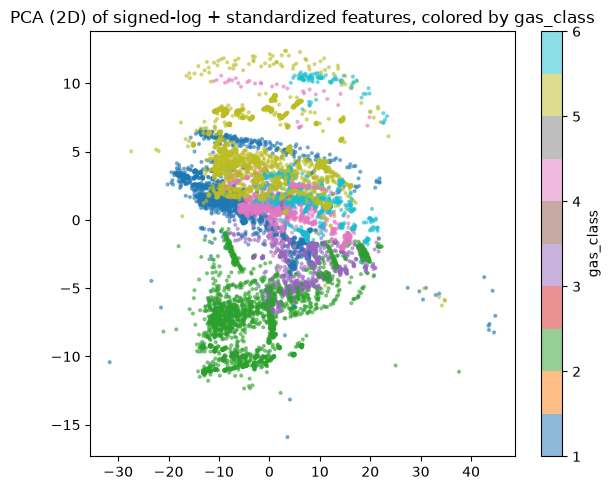

In [16]:
def signed_log(a):
    return np.sign(a) * np.log1p(np.abs(a))

from sklearn.decomposition import PCA
Xlog = StandardScaler().fit_transform(signed_log(train[FEAT].values))
pcs = PCA(n_components=2, random_state=0).fit_transform(Xlog)

fig, ax = plt.subplots(figsize=(6, 5))
sca = ax.scatter(pcs[:, 0], pcs[:, 1], c=train["gas_class"], cmap="tab10", s=4, alpha=0.5)
ax.set_title("PCA (2D) of signed-log + standardized features, colored by gas_class")
plt.colorbar(sca, label="gas_class")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.feature_selection import f_classif
F, p = f_classif(train[FEAT], train["gas_class"])
rank = pd.Series(F, index=FEAT).sort_values(ascending=False)
print("[exploratory, pooled across batches -- ignores drift] top 8 features by class ANOVA F-stat:")
print(rank.head(8))
print()
print("bottom 5 (least informative):")
print(rank.tail(5))

[exploratory, pooled across batches -- ignores drift] top 8 features by class ANOVA F-stat:
feat_9      2250.619703
feat_116    2121.524577
feat_16     2065.464506
feat_15     2040.120610
feat_100    1993.684433
feat_14     1986.288272
feat_60     1936.855743
feat_52     1925.792757
dtype: float64

bottom 5 (least informative):
feat_29    12.333085
feat_40    12.194421
feat_50     2.526294
feat_58     1.370866
feat_42     0.926279
dtype: float64


**Verdict:** classes form visibly distinct, if overlapping, clouds in just 2 PCA
dimensions -- there's real separable signal, encouraging for modeling. Corroborating the
redundancy finding above: `feat_42`, `feat_50`, `feat_58` -- the near-duplicate trio -- are
also the *three least class-informative* features by ANOVA F-stat, out of all 128. Two
independent tests agree these three columns are close to dead weight.

## Summary: graded findings and what they imply for modeling

**Strong** (survived a null-baseline and multiple stratified repeats):
- Train/test is one disjoint held-out batch, not an iid split -- batch 9 vs batch 10 is
  adversarially separable at AUC 0.998. **Use forward-chaining CV** (train on earlier
  batches, validate on a later one); a shuffled row-level split will overstate performance.
- Every adjacent batch pair is nonlinearly separable (AUC 0.90-0.94), even pairs the linear
  centroid-distance metric calls "low drift". **Don't trust a single linear drift score** to
  flag which folds are "hard" -- treat every batch transition as a real domain shift.
- Feature scales span ~5 orders of magnitude and skew is extreme (up to ~100). **A
  scale-fixing transform (e.g. signed-log + standardize) is a prerequisite**, not an
  optional polish, for any model that isn't tree-based.

**Moderate** (clear pattern, single test):
- The 128 features show a strong period-8 sign/scale pattern -- consistent with 16
  sensors x 8 descriptors, group-major. Worth exploiting in feature engineering (e.g.
  per-sensor or per-descriptor grouped transforms) rather than treating all 128 as
  exchangeable.
- `feat_42`, `feat_50`, `feat_58` are near-duplicates (r > 0.999) *and* the three lowest
  ANOVA F-stat features for `gas_class` -- reasonable deadweight-drop candidates, though
  not proven useless (ANOVA here is pooled/exploratory, see below).
- Per-batch class counts are badly imbalanced (as low as 5 rows for one class in one
  batch) even though the overall class balance is reasonable. Expect high-variance,
  not-necessarily-meaningful macro-F1 swings on the smallest batches.

**Exploratory** (one branch among several, not confirmatory):
- The ANOVA feature ranking and the concentration-by-class comparison both pool across all
  9 batches and ignore drift -- useful as a first pass for feature/target intuition, but
  not a substitute for per-fold or per-regime feature importance once modeling starts.
- Concentration alone gives at most a weak, one-sided hint (very high concentration ->
  more likely class 3); it is not a general class discriminator.

**Rejected:**
- "Missing data is a concern here" -- zero missing values anywhere in either file.
- "Some feature columns are exact duplicates" -- closest pairs are r > 0.999 but not 1.0;
  no exact duplicates found.